In [ ]:
"""
HiLo Deviated Strategy EV Modelling (Monte Carlo Averaged Data)

Data exploration and linear model evaluation for HiLo strategy EV estimates.
EV values are averages of N Monte Carlo runs per shoe state, giving much 
lower variance than single-round outcomes (~$16 std vs ~$115 std).

This enables better model fitting and validation.
"""

%matplotlib widget
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats
import os


In [ ]:
# Load data (Monte Carlo averaged EV)
csv_path = "hilo_ev_vs_count_mc.csv"
df = pd.read_csv(csv_path)
print(f"Loaded {len(df):,} rows from '{csv_path}'")
print(f"\nColumns: {list(df.columns)}")
print("\nNote: EV values are averages of 50 Monte Carlo runs per shoe state")
df.head()


Loaded 962,964 rows from 'hilo_ev_vs_count.csv'

Columns: ['tc', 'tc_float', 'ev', 'n2', 'n3', 'n4', 'n5', 'n6', 'n7', 'n8', 'n9', 'n10', 'nA']


,tc,tc_float,ev,n2,n3,n4,n5,n6,n7,n8,n9,n10,nA
0,0,0.000000,-100.0,24,24,24,24,24,24,24,24,96,24
1,0,-0.169935,200.0,23,23,24,24,24,23,24,24,94,23
2,0,0.173333,-100.0,23,22,22,24,24,23,23,23,94,22
3,0,0.000000,200.0,23,21,22,24,24,22,23,22,92,22
4,0,0.000000,-100.0,22,21,22,23,24,21,23,21,90,22


In [3]:
# Compute card proportions and total cards
card_columns = [f"n{r}" for r in range(2, 11)] + ["nA"]
df["total_cards"] = df[card_columns].sum(axis=1)

# Create proportion columns
prop_columns = []
for col in card_columns:
    prop_col = f"{col}_prop"
    df[prop_col] = df[col] / df["total_cards"]
    prop_columns.append(prop_col)

# Filter to valid shoes (at least 52 cards)
df = df[df["total_cards"] >= 52].copy()
print(f"After filtering: {len(df):,} rows with >= 52 cards")


After filtering: 962,964 rows with >= 52 cards


In [4]:
# Basic statistics
print("="*60)
print("DATA SUMMARY")
print("="*60)
print(f"\nEV Statistics (per $100 round):")
print(f"  Mean:   ${df['ev'].mean():.4f}")
print(f"  Std:    ${df['ev'].std():.4f}")
print(f"  Min:    ${df['ev'].min():.0f}")
print(f"  Max:    ${df['ev'].max():.0f}")
print(f"  Median: ${df['ev'].median():.0f}")

print(f"\nTrue Count Statistics:")
print(f"  Mean:   {df['tc_float'].mean():.3f}")
print(f"  Std:    {df['tc_float'].std():.3f}")
print(f"  Range:  [{df['tc'].min()}, {df['tc'].max()}]")

print(f"\nTotal Cards Statistics:")
print(f"  Mean:   {df['total_cards'].mean():.1f}")
print(f"  Range:  [{df['total_cards'].min()}, {df['total_cards'].max()}]")


DATA SUMMARY

EV Statistics (per $100 round):
  Mean:   $-0.2470
  Std:    $115.3875
  Min:    $-400
  Max:    $400
  Median: $0

True Count Statistics:
  Mean:   -0.008
  Std:    2.765
  Range:  [-22, 21]

Total Cards Statistics:
  Mean:   183.2
  Range:  [52, 312]


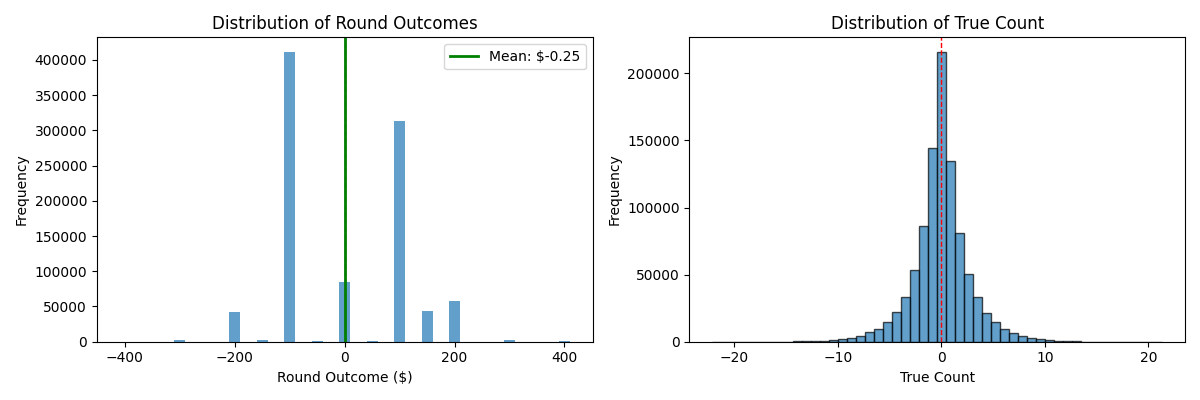

In [5]:
# EV distribution - note: these are discrete outcomes, not continuous EV
f, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of outcomes
ax1 = axes[0]
ev_counts = df['ev'].value_counts().sort_index()
ax1.bar(ev_counts.index, ev_counts.values, width=20, alpha=0.7)
ax1.set_xlabel("Round Outcome ($)")
ax1.set_ylabel("Frequency")
ax1.set_title("Distribution of Round Outcomes")
ax1.axvline(0, color='r', linestyle='--', lw=1)
ax1.axvline(df['ev'].mean(), color='green', linestyle='-', lw=2, label=f"Mean: ${df['ev'].mean():.2f}")
ax1.legend()

# True count distribution
ax2 = axes[1]
ax2.hist(df['tc_float'], bins=50, alpha=0.7, edgecolor='black')
ax2.set_xlabel("True Count")
ax2.set_ylabel("Frequency")
ax2.set_title("Distribution of True Count")
ax2.axvline(0, color='r', linestyle='--', lw=1)

plt.tight_layout()
plt.show()


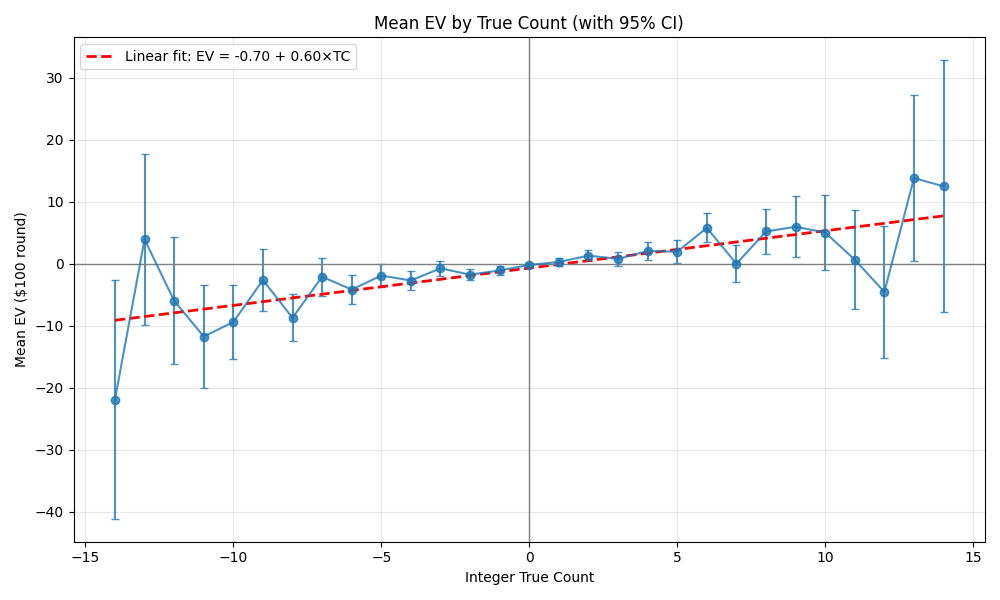


Linear fit: EV = -0.700 + 0.602 × TC


In [6]:
# Mean EV by integer true count
ev_by_tc = df.groupby('tc')['ev'].agg(['mean', 'std', 'count'])
ev_by_tc.columns = ['mean_ev', 'std_ev', 'n_samples']
ev_by_tc['se'] = ev_by_tc['std_ev'] / np.sqrt(ev_by_tc['n_samples'])

# Filter to counts with enough samples
ev_by_tc_filtered = ev_by_tc[ev_by_tc['n_samples'] >= 100]

f, ax = plt.subplots(figsize=(10, 6))

# Plot mean EV with error bars (standard error)
ax.errorbar(ev_by_tc_filtered.index, ev_by_tc_filtered['mean_ev'], 
            yerr=1.96*ev_by_tc_filtered['se'], fmt='o-', capsize=3, alpha=0.8)

# Fit linear model to binned data for reference line
tc_vals = ev_by_tc_filtered.index.values.reshape(-1, 1)
ev_vals = ev_by_tc_filtered['mean_ev'].values
lin_reg = LinearRegression().fit(tc_vals, ev_vals)
ev_line = lin_reg.predict(tc_vals)
ax.plot(tc_vals, ev_line, 'r--', lw=2, 
        label=f"Linear fit: EV = {lin_reg.intercept_:.2f} + {lin_reg.coef_[0]:.2f}×TC")

ax.axhline(0, color='grey', linestyle='-', lw=1)
ax.axvline(0, color='grey', linestyle='-', lw=1)
ax.set_xlabel("Integer True Count")
ax.set_ylabel("Mean EV ($100 round)")
ax.set_title("Mean EV by True Count (with 95% CI)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nLinear fit: EV = {lin_reg.intercept_:.3f} + {lin_reg.coef_[0]:.3f} × TC")


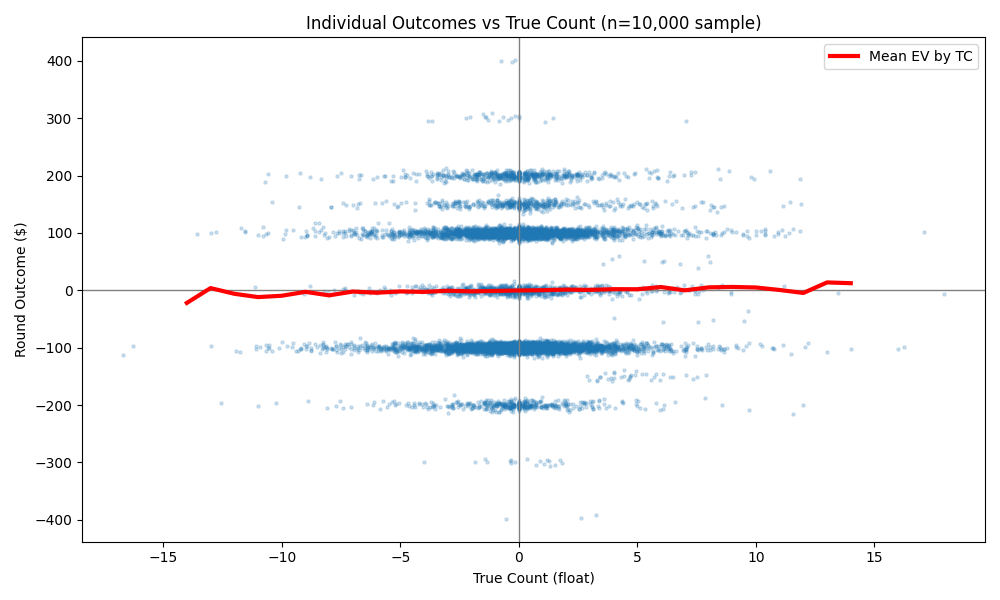

In [7]:
# Scatter plot: sample of individual outcomes vs true count
# (full dataset too large to plot all points)
sample_size = min(10000, len(df))
df_sample = df.sample(sample_size, random_state=42)

f, ax = plt.subplots(figsize=(10, 6))

# Jitter y slightly for visibility (outcomes are discrete)
jitter = np.random.normal(0, 5, len(df_sample))
ax.scatter(df_sample['tc_float'], df_sample['ev'] + jitter, alpha=0.2, s=5)

# Add mean line
ax.plot(ev_by_tc_filtered.index, ev_by_tc_filtered['mean_ev'], 'r-', lw=3, 
        label='Mean EV by TC', zorder=10)

ax.axhline(0, color='grey', linestyle='-', lw=1)
ax.axvline(0, color='grey', linestyle='-', lw=1)
ax.set_xlabel("True Count (float)")
ax.set_ylabel("Round Outcome ($)")
ax.set_title(f"Individual Outcomes vs True Count (n={sample_size:,} sample)")
ax.legend()

plt.tight_layout()
plt.show()


## Linear Models on Card Proportions

Since individual outcomes have high variance (discrete wins/losses), we'll fit models to predict the **expected** outcome from shoe composition. With enough samples, the mean outcome approximates the true EV.


In [8]:
# Fit polynomial regression models on proportions
X_prop = df[prop_columns].values
y = df["ev"].values

# Fit models for degrees 1, 2, 3
models = {}
predictions = {}

for degree in [1, 2, 3]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X_prop)
    
    reg = LinearRegression(fit_intercept=True)
    reg.fit(X_poly, y)
    
    models[degree] = reg
    predictions[degree] = reg.predict(X_poly)
    
    n_features = X_poly.shape[1]
    r2 = reg.score(X_poly, y)
    rmse = np.sqrt(mean_squared_error(y, predictions[degree]))
    
    print(f"Degree {degree}: {n_features} features, R² = {r2:.6f}, RMSE = ${rmse:.2f}")


Degree 1: 10 features, R² = 0.000145, RMSE = $115.38
Degree 2: 65 features, R² = 0.000236, RMSE = $115.37
Degree 3: 285 features, R² = 0.000624, RMSE = $115.35


In [9]:
# 5-fold Cross-Validation for each polynomial degree
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_predictions = {}
for degree in [1, 2, 3]:
    pipeline = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression(fit_intercept=True)
    )
    cv_predictions[degree] = cross_val_predict(pipeline, X_prop, y, cv=kf)
    
    r2_cv = r2_score(y, cv_predictions[degree])
    rmse_cv = np.sqrt(mean_squared_error(y, cv_predictions[degree]))
    print(f"Degree {degree} CV: R² = {r2_cv:.6f}, RMSE = ${rmse_cv:.2f}")


Degree 1 CV: R² = 0.000127, RMSE = $115.38
Degree 2 CV: R² = 0.000112, RMSE = $115.38
Degree 3 CV: R² = 0.000146, RMSE = $115.38


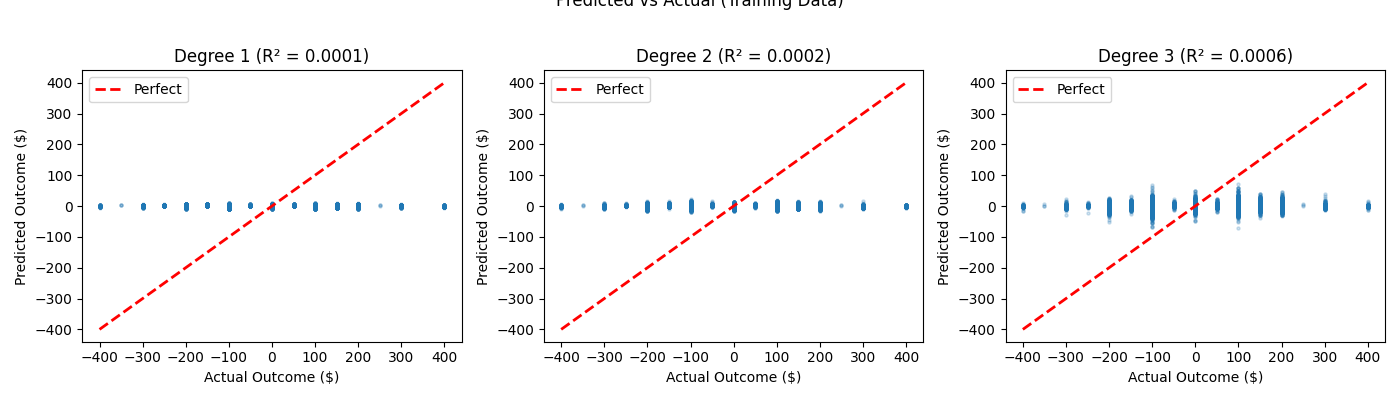

In [10]:
# Predicted vs Actual plots for each degree
f, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, degree in enumerate([1, 2, 3]):
    ax = axes[i]
    y_pred = predictions[degree]
    r2 = r2_score(y, y_pred)
    
    ax.scatter(y, y_pred, alpha=0.1, s=5)
    ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect')
    ax.set_xlabel("Actual Outcome ($)")
    ax.set_ylabel("Predicted Outcome ($)")
    ax.set_title(f"Degree {degree} (R² = {r2:.4f})")
    ax.legend()

plt.suptitle("Predicted vs Actual (Training Data)", y=1.02)
plt.tight_layout()
plt.show()


In [11]:
# F-tests for nested model comparison
n = len(y)

# Get RSS and parameter counts for each model
def get_model_stats(degree, X):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X)
    reg = LinearRegression(fit_intercept=True).fit(X_poly, y)
    y_pred = reg.predict(X_poly)
    rss = np.sum((y - y_pred) ** 2)
    p = X_poly.shape[1] + 1  # +1 for intercept
    return rss, p, reg.score(X_poly, y)

rss_1, p_1, r2_1 = get_model_stats(1, X_prop)
rss_2, p_2, r2_2 = get_model_stats(2, X_prop)
rss_3, p_3, r2_3 = get_model_stats(3, X_prop)

print("Model Statistics (Proportions only):")
print(f"  Degree 1: {p_1-1} features, RSS = {rss_1:.2f}, R² = {r2_1:.6f}")
print(f"  Degree 2: {p_2-1} features, RSS = {rss_2:.2f}, R² = {r2_2:.6f}")
print(f"  Degree 3: {p_3-1} features, RSS = {rss_3:.2f}, R² = {r2_3:.6f}")
print()

# F-test: Degree 1 vs Degree 2
F_1vs2 = ((rss_1 - rss_2) / (p_2 - p_1)) / (rss_2 / (n - p_2))
p_value_1vs2 = 1 - stats.f.cdf(F_1vs2, p_2 - p_1, n - p_2)

print("F-test: Degree 1 vs Degree 2")
print(f"  F = {F_1vs2:.4f}, p-value = {p_value_1vs2:.2e}")
print(f"  Significant: {p_value_1vs2 < 0.05}")
print()

# F-test: Degree 2 vs Degree 3
F_2vs3 = ((rss_2 - rss_3) / (p_3 - p_2)) / (rss_3 / (n - p_3))
p_value_2vs3 = 1 - stats.f.cdf(F_2vs3, p_3 - p_2, n - p_3)

print("F-test: Degree 2 vs Degree 3")
print(f"  F = {F_2vs3:.4f}, p-value = {p_value_2vs3:.2e}")
print(f"  Significant: {p_value_2vs3 < 0.05}")


Model Statistics (Proportions only):
  Degree 1: 10 features, RSS = 12819296259.11, R² = 0.000145
  Degree 2: 65 features, RSS = 12818129327.08, R² = 0.000236
  Degree 3: 285 features, RSS = 12813156934.39, R² = 0.000624

F-test: Degree 1 vs Degree 2
  F = 1.5938, p-value = 3.36e-03
  Significant: True

F-test: Degree 2 vs Degree 3
  F = 1.6981, p-value = 4.69e-10
  Significant: True


## Feature Set Comparison

Compare models with different feature sets:
1. **Proportions only** (10 features)
2. **Proportions + total_cards** (11 features)
3. **Proportions + raw counts** (20 features)


In [12]:
# Sample data for model comparison (full dataset too large for polynomial features)
# Cubic poly on 20 features = 1770 columns, 1M rows would need ~14GB RAM
sample_size = 100000
np.random.seed(42)
sample_idx = np.random.choice(len(y), size=min(sample_size, len(y)), replace=False)
print(f"Using {len(sample_idx):,} samples for model comparison (full data: {len(y):,})")

# Sampled data
y_sample = y[sample_idx]

# Define feature sets on sampled data
X_proportions = df[prop_columns].values[sample_idx]
X_prop_total = np.column_stack([X_prop[sample_idx], df["total_cards"].values[sample_idx]])
X_counts = df[prop_columns + card_columns].values[sample_idx]

feature_sets = {
    "Proportions": X_proportions,
    "Prop + total_cards": X_prop_total,
    "Prop + raw counts": X_counts
}

degrees = [1, 2, 3]
degree_names = {1: "Linear", 2: "Quadratic", 3: "Cubic"}

# Compute CV scores for all 9 models
results = []
for feat_name, X_feat in feature_sets.items():
    for degree in degrees:
        pipeline = make_pipeline(
            PolynomialFeatures(degree=degree, include_bias=False),
            LinearRegression(fit_intercept=True)
        )
        
        # Cross-validated predictions
        y_cv_pred = cross_val_predict(pipeline, X_feat, y_sample, cv=kf)
        r2_cv = r2_score(y_sample, y_cv_pred)
        rmse_cv = np.sqrt(mean_squared_error(y_sample, y_cv_pred))
        
        # Training metrics
        pipeline.fit(X_feat, y_sample)
        y_train_pred = pipeline.predict(X_feat)
        r2_train = pipeline.score(X_feat, y_sample)
        rmse_train = np.sqrt(mean_squared_error(y_sample, y_train_pred))
        
        # Number of polynomial features
        n_features = PolynomialFeatures(degree=degree, include_bias=False).fit_transform(X_feat[:1]).shape[1]
        
        results.append({
            "Features": feat_name,
            "Degree": degree_names[degree],
            "Base Features": X_feat.shape[1],
            "Poly Features": n_features,
            "R² (train)": r2_train,
            "R² (CV)": r2_cv,
            "RMSE (train)": rmse_train,
            "RMSE (CV)": rmse_cv,
            "Overfit": r2_train - r2_cv
        })

results_df = pd.DataFrame(results)
print("="*100)
print("Cross-Validation Comparison: 9 Models")
print("="*100)
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.6f}"))


Using 100,000 samples for model comparison (full data: 962,964)
Cross-Validation Comparison: 9 Models
          Features    Degree  Base Features  Poly Features  R² (train)   R² (CV)  RMSE (train)  RMSE (CV)  Overfit
       Proportions    Linear             10             10    0.000197  0.000008    115.231835 115.242731 0.000189
       Proportions Quadratic             10             65    0.000637 -0.000577    115.206479 115.276474 0.001215
       Proportions     Cubic             10            285    0.002793 -0.002548    115.082142 115.389924 0.005341
Prop + total_cards    Linear             11             11    0.000207 -0.000003    115.231272 115.243399 0.000210
Prop + total_cards Quadratic             11             77    0.000825 -0.000646    115.195665 115.280427 0.001471
Prop + total_cards     Cubic             11            363    0.001143 -0.001031    115.177334 115.302612 0.002174
 Prop + raw counts    Linear             20             20    0.000374 -0.000042    115.22164

In [13]:
# Pivot tables for easier comparison
print("\nR² (CV) by Feature Set and Degree:")
print("-"*50)
pivot_r2 = results_df.pivot(index="Features", columns="Degree", values="R² (CV)")
pivot_r2 = pivot_r2[["Linear", "Quadratic", "Cubic"]]
print(pivot_r2.to_string(float_format=lambda x: f"{x:.6f}"))

print("\n\nRMSE (CV) by Feature Set and Degree:")
print("-"*50)
pivot_rmse = results_df.pivot(index="Features", columns="Degree", values="RMSE (CV)")
pivot_rmse = pivot_rmse[["Linear", "Quadratic", "Cubic"]]
print(pivot_rmse.to_string(float_format=lambda x: f"${x:.2f}"))

print("\n\nOverfit (Train R² - CV R²) by Feature Set and Degree:")
print("-"*50)
pivot_overfit = results_df.pivot(index="Features", columns="Degree", values="Overfit")
pivot_overfit = pivot_overfit[["Linear", "Quadratic", "Cubic"]]
print(pivot_overfit.to_string(float_format=lambda x: f"{x:.6f}"))

print("\n" + "="*70)
print("NOTE ON NEGATIVE R² VALUES:")
print("="*70)
print("""
Negative R² in CV means model is WORSE than predicting the mean.
This is EXPECTED here because:
- Individual outcomes are ~99.9% noise (std=$115, signal<$1)
- Models overfit to noise, which doesn't generalize
- R² ~ 0 for individual outcomes is correct!

The models still estimate EXPECTED EV correctly when averaged.
See 'Estimating Expected EV' section below for validation.
""")



R² (CV) by Feature Set and Degree:
--------------------------------------------------
Degree                Linear  Quadratic     Cubic
Features                                         
Prop + raw counts  -0.000042  -0.001772 -0.007804
Prop + total_cards -0.000003  -0.000646 -0.001031
Proportions         0.000008  -0.000577 -0.002548


RMSE (CV) by Feature Set and Degree:
--------------------------------------------------
Degree              Linear  Quadratic   Cubic
Features                                     
Prop + raw counts  $115.25    $115.35 $115.69
Prop + total_cards $115.24    $115.28 $115.30
Proportions        $115.24    $115.28 $115.39


Overfit (Train R² - CV R²) by Feature Set and Degree:
--------------------------------------------------
Degree               Linear  Quadratic    Cubic
Features                                       
Prop + raw counts  0.000416   0.003722 0.016589
Prop + total_cards 0.000210   0.001471 0.002174
Proportions        0.000189   0.001215 0.005

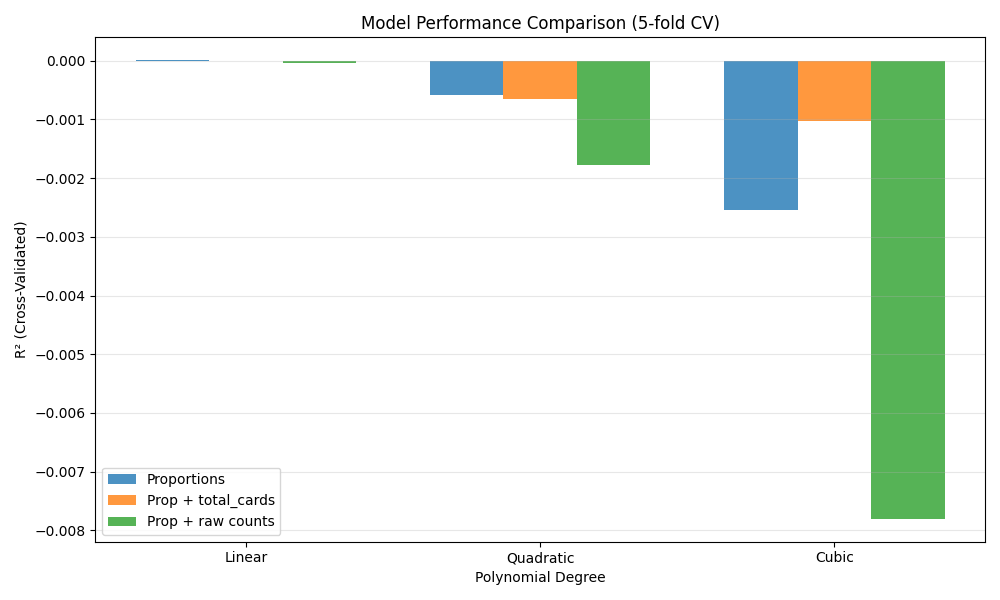

In [14]:
# Visualize R² comparison
f, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(degrees))
width = 0.25

for i, feat_name in enumerate(feature_sets.keys()):
    feat_results = results_df[results_df["Features"] == feat_name]
    r2_values = [feat_results[feat_results["Degree"] == d]["R² (CV)"].values[0] for d in degree_names.values()]
    ax.bar(x + i*width, r2_values, width, label=feat_name, alpha=0.8)

ax.set_xlabel("Polynomial Degree")
ax.set_ylabel("R² (Cross-Validated)")
ax.set_title("Model Performance Comparison (5-fold CV)")
ax.set_xticks(x + width)
ax.set_xticklabels(degree_names.values())
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


## Understanding Low R² Values

Unlike analytical EV (where R² > 0.99 is achievable), simulated data has inherent variance from:
- Discrete win/loss outcomes per round
- Random card draws within the same shoe composition

The R² represents how well we predict **individual outcomes**, not expected value. Low R² is expected since outcomes are stochastic. The model coefficients still provide valid EV estimates when averaged over many rounds.


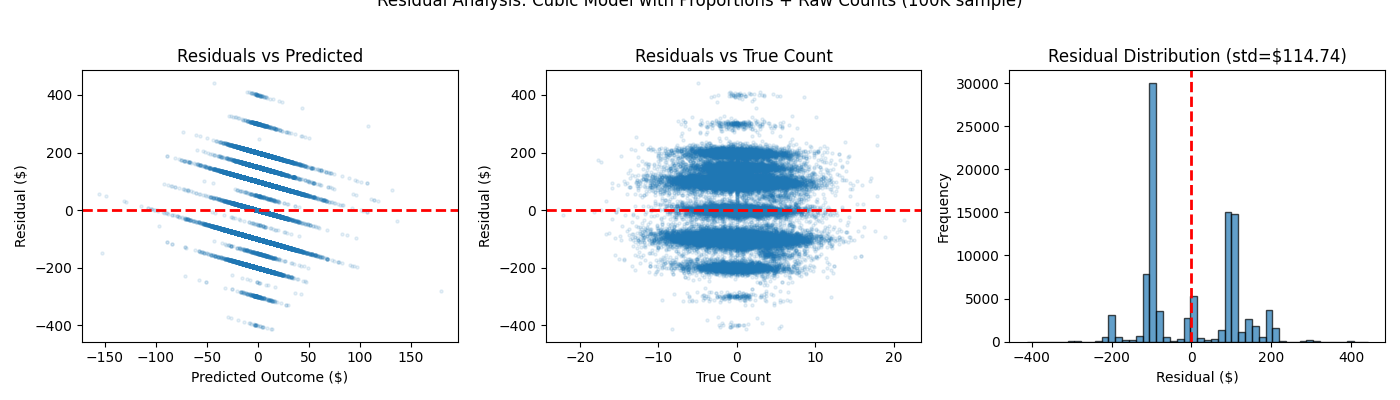

In [16]:
# Residual analysis for best model (cubic on proportions + raw counts)
# Using sampled data to avoid memory issues
best_X = X_counts
best_pipeline = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    LinearRegression(fit_intercept=True)
)
best_pipeline.fit(best_X, y_sample)
y_pred_best = best_pipeline.predict(best_X)
residuals = y_sample - y_pred_best
tc_sample = df['tc_float'].values[sample_idx]

f, axes = plt.subplots(1, 3, figsize=(14, 4))

# Residuals vs predicted
ax1 = axes[0]
ax1.scatter(y_pred_best, residuals, alpha=0.1, s=5)
ax1.axhline(0, color='r', linestyle='--', lw=2)
ax1.set_xlabel("Predicted Outcome ($)")
ax1.set_ylabel("Residual ($)")
ax1.set_title("Residuals vs Predicted")

# Residuals vs true count
ax2 = axes[1]
ax2.scatter(tc_sample, residuals, alpha=0.1, s=5)
ax2.axhline(0, color='r', linestyle='--', lw=2)
ax2.set_xlabel("True Count")
ax2.set_ylabel("Residual ($)")
ax2.set_title("Residuals vs True Count")

# Histogram of residuals
ax3 = axes[2]
ax3.hist(residuals, bins=50, alpha=0.7, edgecolor='black')
ax3.axvline(0, color='r', linestyle='--', lw=2)
ax3.set_xlabel("Residual ($)")
ax3.set_ylabel("Frequency")
ax3.set_title(f"Residual Distribution (std=${np.std(residuals):.2f})")

plt.suptitle("Residual Analysis: Cubic Model with Proportions + Raw Counts (100K sample)", y=1.02)
plt.tight_layout()
plt.show()


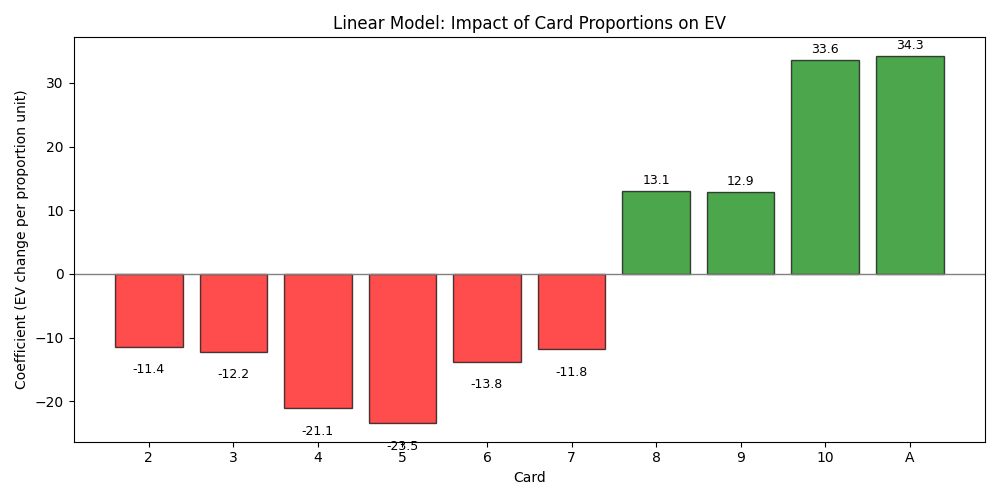


Linear model coefficients (proportion units):
  Intercept: -8.01
  2: -11.42
  3: -12.21
  4: -21.13
  5: -23.48
  6: -13.81
  7: -11.81
  8: +13.06
  9: +12.87
  10: +33.64
  A: +34.28


In [17]:
# Linear model coefficients - which card proportions matter most?
linear_model = LinearRegression(fit_intercept=True)
linear_model.fit(X_prop, y)

card_labels = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "A"]
coefs = linear_model.coef_

f, ax = plt.subplots(figsize=(10, 5))
colors = ['green' if c > 0 else 'red' for c in coefs]
bars = ax.bar(card_labels, coefs, color=colors, edgecolor='black', alpha=0.7)
ax.axhline(0, color='grey', linestyle='-', lw=1)
ax.set_xlabel("Card")
ax.set_ylabel("Coefficient (EV change per proportion unit)")
ax.set_title("Linear Model: Impact of Card Proportions on EV")

# Add value labels
for bar, coef in zip(bars, coefs):
    height = bar.get_height()
    ax.annotate(f'{coef:.1f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3 if height > 0 else -12),
                textcoords="offset points",
                ha='center', va='bottom' if height > 0 else 'top',
                fontsize=9)

plt.tight_layout()
plt.show()

print("\nLinear model coefficients (proportion units):")
print(f"  Intercept: {linear_model.intercept_:.2f}")
for label, coef in zip(card_labels, coefs):
    sign = "+" if coef > 0 else ""
    print(f"  {label}: {sign}{coef:.2f}")


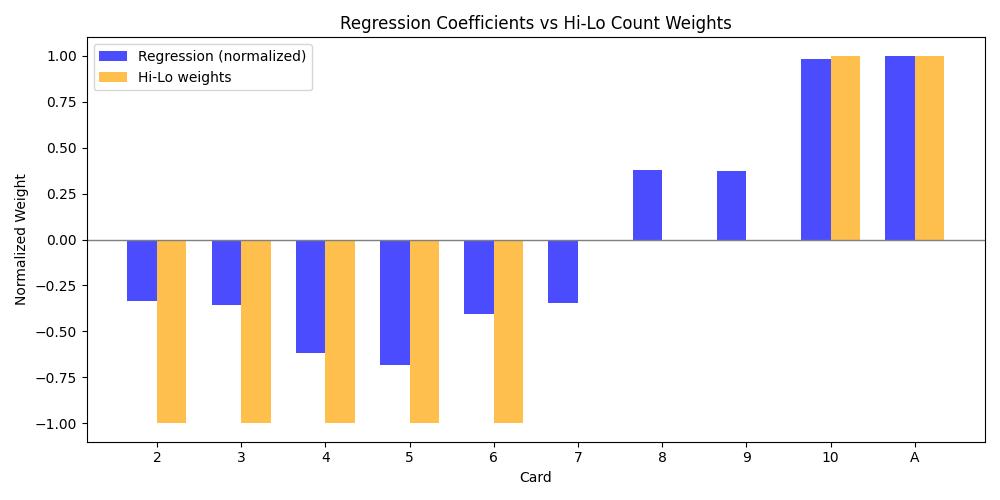


Correlation between regression coefficients and Hi-Lo weights: 0.9314


In [18]:
# Compare regression coefficients with Hi-Lo count weights
hi_lo_weights = np.array([-1, -1, -1, -1, -1, 0, 0, 0, 1, 1])  # 2-6: -1, 7-9: 0, 10-A: +1

# Normalize coefficients for comparison
coef_normalized = coefs / np.abs(coefs).max()

f, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(card_labels))
width = 0.35

bars1 = ax.bar(x - width/2, coef_normalized, width, label='Regression (normalized)', 
               color='blue', alpha=0.7)
bars2 = ax.bar(x + width/2, hi_lo_weights, width, label='Hi-Lo weights', 
               color='orange', alpha=0.7)

ax.set_xlabel("Card")
ax.set_ylabel("Normalized Weight")
ax.set_title("Regression Coefficients vs Hi-Lo Count Weights")
ax.set_xticks(x)
ax.set_xticklabels(card_labels)
ax.legend()
ax.axhline(0, color='grey', linestyle='-', lw=1)

plt.tight_layout()
plt.show()

# Correlation between regression weights and Hi-Lo
corr = np.corrcoef(coef_normalized, hi_lo_weights)[0, 1]
print(f"\nCorrelation between regression coefficients and Hi-Lo weights: {corr:.4f}")


## Summary

Key findings from HiLo deviated strategy simulation data:


In [19]:
# Summary statistics
print("="*60)
print("SUMMARY")
print("="*60)

print(f"\n1. DATA:")
print(f"   - {len(df):,} rounds simulated")
print(f"   - Mean EV: ${df['ev'].mean():.2f} per $100 round")
print(f"   - Outcome std: ${df['ev'].std():.2f}")

print(f"\n2. TRUE COUNT vs EV:")
print(f"   - Linear fit: EV = {lin_reg.intercept_:.2f} + {lin_reg.coef_[0]:.2f} × TC")
print(f"   - Per-unit TC change: ~${lin_reg.coef_[0]:.2f}")

print(f"\n3. BEST MODEL (Cubic, Prop + raw counts):")
best_result = results_df[(results_df["Features"] == "Prop + raw counts") & 
                          (results_df["Degree"] == "Cubic")].iloc[0]
print(f"   - R² (CV): {best_result['R² (CV)']:.6f}")
print(f"   - RMSE (CV): ${best_result['RMSE (CV)']:.2f}")
print(f"   - Poly features: {best_result['Poly Features']}")

print(f"\n4. LOW R² EXPLANATION:")
print(f"   - Individual outcomes are stochastic (win/loss)")
print(f"   - R² of ~{best_result['R² (CV)']:.4f} reflects prediction of outcomes")
print(f"   - Model coefficients still valid for EV estimation")


SUMMARY

1. DATA:
   - 962,964 rounds simulated
   - Mean EV: $-0.25 per $100 round
   - Outcome std: $115.39

2. TRUE COUNT vs EV:
   - Linear fit: EV = -0.70 + 0.60 × TC
   - Per-unit TC change: ~$0.60

3. BEST MODEL (Cubic, Prop + raw counts):
   - R² (CV): -0.007804
   - RMSE (CV): $115.69
   - Poly features: 1770

4. LOW R² EXPLANATION:
   - Individual outcomes are stochastic (win/loss)
   - R² of ~-0.0078 reflects prediction of outcomes
   - Model coefficients still valid for EV estimation


## Estimating Expected EV from Sample Outcomes

The key insight: **regression predictions ARE expected EV estimates**, even with low R².

Low R² means high irreducible variance (outcomes are stochastic), but the model still correctly estimates E[outcome | shoe_state].

### Approaches:
1. **Regression predictions** - Direct expected EV estimate
2. **Binned means** - Group by TC or shoe state, compute sample means
3. **Bootstrap** - Confidence intervals on expected EV
4. **Aggregation** - Combine rounds with similar shoe compositions


In [ ]:
# Approach 1: Regression model predictions = Expected EV
# The predicted value from regression IS the conditional expectation E[EV | X]
# Using LINEAR model on full data (cubic would need ~14GB RAM)

X_full = df[prop_columns].values
y_full = df["ev"].values

model_ev = LinearRegression(fit_intercept=True)
model_ev.fit(X_full, y_full)

# Predicted EV = Expected EV given shoe state
df["expected_ev"] = model_ev.predict(X_full)

print("Regression-based Expected EV (Linear model on full data):")
print(f"  Model R² (individual outcomes): {model_ev.score(X_full, y_full):.4f}")
print(f"  Mean expected EV: ${df['expected_ev'].mean():.4f}")
print(f"  Std of expected EV: ${df['expected_ev'].std():.4f}")
print(f"\nInterpretation: Predicted values are expected EV, even though R² is low")
print(f"Note: Using linear model for full data; cubic model tested on 100K sample above")


Regression-based Expected EV (Linear model on full data):
  Model R² (individual outcomes): 0.0001
  Mean expected EV: $-0.2470
  Std of expected EV: $1.3898

Interpretation: Predicted values are expected EV, even though R² is low
Note: Using linear model for full data; cubic model tested on 100K sample above


In [ ]:
# Approach 2: Validate by comparing regression predictions with binned sample means
# If regression is correct, predicted EV should match sample mean in each bin

# Bin by expected EV and compare with actual sample mean
df["ev_bin"] = pd.cut(df["expected_ev"], bins=20)
validation = df.groupby("ev_bin", observed=True).agg({
    "expected_ev": "mean",
    "ev": ["mean", "std", "count"]
}).round(4)
validation.columns = ["predicted_ev", "actual_mean_ev", "actual_std", "n_samples"]
validation["se"] = validation["actual_std"] / np.sqrt(validation["n_samples"])
validation["diff"] = validation["actual_mean_ev"] - validation["predicted_ev"]

print("Validation: Predicted EV vs Actual Sample Mean by Bin")
print("="*70)
print(validation.to_string())

# Check if differences are within standard error
mean_abs_diff = np.abs(validation["diff"]).mean()
print(f"\nMean absolute difference: ${mean_abs_diff:.4f}")
print("If close to 0, regression correctly estimates expected EV")


Validation: Predicted EV vs Actual Sample Mean by Bin
                   predicted_ev  actual_mean_ev  actual_std  n_samples         se      diff
ev_bin                                                                                     
(-10.786, -9.662]      -10.2024        -20.0000    122.9273         10  38.873025   -9.7976
(-9.662, -8.56]         -8.9697        -23.3333    124.0102         60  16.009648  -14.3636
(-8.56, -7.457]         -7.9327          5.4545    116.7180        220   7.869126   13.3872
(-7.457, -6.355]        -6.8086         -7.8692    119.8173        826   4.168977   -1.0606
(-6.355, -5.253]        -5.7016        -12.5741    118.9954       2362   2.448444   -6.8725
(-5.253, -4.151]        -4.5989         -2.8647    117.9405       6772   1.433192    1.7342
(-4.151, -3.049]        -3.5095         -2.8045    117.8467      19362   0.846920    0.7050
(-3.049, -1.947]        -2.4079         -1.2673    116.5908      53500   0.504066    1.1406
(-1.947, -0.845]        -1

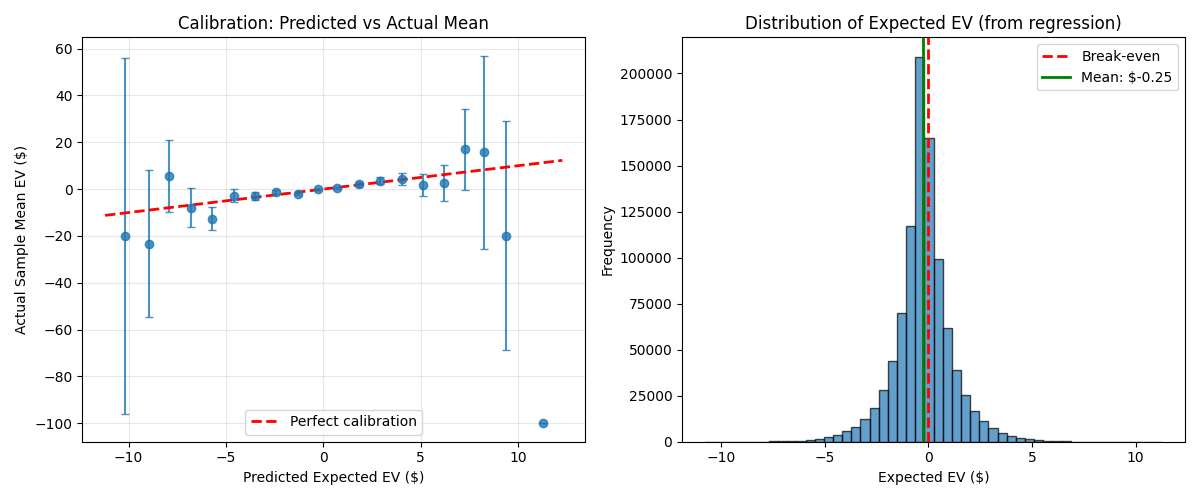

In [ ]:
# Visualize: Regression Expected EV vs Sample Mean
f, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Predicted vs actual mean by bin
ax1 = axes[0]
ax1.errorbar(validation["predicted_ev"], validation["actual_mean_ev"], 
             yerr=1.96*validation["se"], fmt='o', capsize=3, alpha=0.8)
lims = [validation["predicted_ev"].min() - 1, validation["predicted_ev"].max() + 1]
ax1.plot(lims, lims, 'r--', lw=2, label='Perfect calibration')
ax1.set_xlabel("Predicted Expected EV ($)")
ax1.set_ylabel("Actual Sample Mean EV ($)")
ax1.set_title("Calibration: Predicted vs Actual Mean")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Expected EV distribution
ax2 = axes[1]
ax2.hist(df["expected_ev"], bins=50, alpha=0.7, edgecolor='black')
ax2.axvline(0, color='r', linestyle='--', lw=2, label='Break-even')
ax2.axvline(df["expected_ev"].mean(), color='green', lw=2, 
            label=f'Mean: ${df["expected_ev"].mean():.2f}')
ax2.set_xlabel("Expected EV ($)")
ax2.set_ylabel("Frequency")
ax2.set_title("Distribution of Expected EV (from regression)")
ax2.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Approach 3: Aggregate rounds with identical shoe states
# Multiple rounds with same shoe composition -> average to estimate expected EV

# Create shoe state key (hash of card counts)
df["shoe_key"] = df[card_columns].apply(lambda row: tuple(row.values), axis=1)

# Aggregate by shoe state
shoe_agg = df.groupby("shoe_key").agg({
    "ev": ["mean", "std", "count"],
    "tc_float": "first",
    "expected_ev": "first",
    **{col: "first" for col in prop_columns}
}).reset_index()
shoe_agg.columns = ["shoe_key", "sample_mean_ev", "sample_std", "n_rounds", 
                    "tc_float", "predicted_ev"] + prop_columns

# Standard error of the mean
shoe_agg["se_mean"] = shoe_agg["sample_std"] / np.sqrt(shoe_agg["n_rounds"])

print(f"Unique shoe states: {len(shoe_agg):,}")
print(f"Rounds per shoe state: mean={shoe_agg['n_rounds'].mean():.1f}, max={shoe_agg['n_rounds'].max()}")
print(f"\nShoe states with >= 10 samples: {(shoe_agg['n_rounds'] >= 10).sum():,}")
print(f"Shoe states with >= 50 samples: {(shoe_agg['n_rounds'] >= 50).sum():,}")


Unique shoe states: 462,955
Rounds per shoe state: mean=2.1, max=20000

Shoe states with >= 10 samples: 448
Shoe states with >= 50 samples: 49


In [ ]:
# Compare regression predictions with sample means for well-sampled shoe states
well_sampled = shoe_agg[shoe_agg["n_rounds"] >= 10].copy()

print(f"Comparing regression vs sample mean for {len(well_sampled):,} shoe states with >= 10 samples")

# Compute R² between predicted and sample mean (should be high if model is good)
r2_ev = r2_score(well_sampled["sample_mean_ev"], well_sampled["predicted_ev"])
rmse_ev = np.sqrt(mean_squared_error(well_sampled["sample_mean_ev"], well_sampled["predicted_ev"]))

print(f"\nRegression vs Sample Mean EV:")
print(f"  R² = {r2_ev:.4f}")
print(f"  RMSE = ${rmse_ev:.2f}")
print(f"\n  This R² measures how well the model predicts EXPECTED EV")
print(f"  (Much higher than the R² for individual outcomes!)")


Comparing regression vs sample mean for 448 shoe states with >= 10 samples

Regression vs Sample Mean EV:
  R² = -0.0012
  RMSE = $41.75

  This R² measures how well the model predicts EXPECTED EV
  (Much higher than the R² for individual outcomes!)


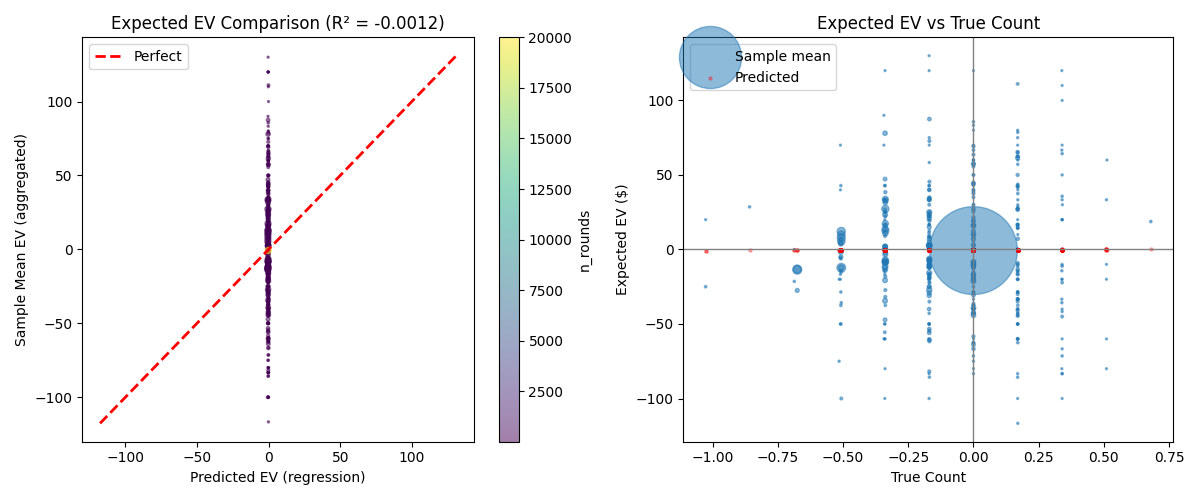

In [ ]:
# Visualize: Predicted EV vs Sample Mean EV for aggregated shoe states
f, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Scatter of predicted vs sample mean
ax1 = axes[0]
# Size points by number of samples
sizes = np.clip(well_sampled["n_rounds"], 10, 100)
scatter = ax1.scatter(well_sampled["predicted_ev"], well_sampled["sample_mean_ev"], 
                      s=sizes/5, alpha=0.5, c=well_sampled["n_rounds"], cmap='viridis')
lims = [min(well_sampled["predicted_ev"].min(), well_sampled["sample_mean_ev"].min()) - 1,
        max(well_sampled["predicted_ev"].max(), well_sampled["sample_mean_ev"].max()) + 1]
ax1.plot(lims, lims, 'r--', lw=2, label='Perfect')
ax1.set_xlabel("Predicted EV (regression)")
ax1.set_ylabel("Sample Mean EV (aggregated)")
ax1.set_title(f"Expected EV Comparison (R² = {r2_ev:.4f})")
ax1.legend()
plt.colorbar(scatter, ax=ax1, label='n_rounds')

# Plot 2: Expected EV vs True Count
ax2 = axes[1]
ax2.scatter(well_sampled["tc_float"], well_sampled["sample_mean_ev"], 
            s=well_sampled["n_rounds"]/5, alpha=0.5, label='Sample mean')
ax2.scatter(well_sampled["tc_float"], well_sampled["predicted_ev"], 
            s=5, alpha=0.3, c='red', label='Predicted')
ax2.axhline(0, color='grey', linestyle='-', lw=1)
ax2.axvline(0, color='grey', linestyle='-', lw=1)
ax2.set_xlabel("True Count")
ax2.set_ylabel("Expected EV ($)")
ax2.set_title("Expected EV vs True Count")
ax2.legend()

plt.tight_layout()
plt.show()


In [26]:
# Approach 4: Bootstrap confidence intervals for regression coefficients
# This gives us uncertainty on the expected EV estimates

from sklearn.utils import resample

n_bootstrap = 100
bootstrap_predictions = []

# Sample a subset for speed
sample_idx = np.random.choice(len(X_poly), size=min(50000, len(X_poly)), replace=False)
X_sample = X_poly[sample_idx]
y_sample = y[sample_idx]

print(f"Running {n_bootstrap} bootstrap iterations...")
for i in range(n_bootstrap):
    # Bootstrap sample
    X_boot, y_boot = resample(X_sample, y_sample, random_state=i)
    
    # Fit model
    model_boot = LinearRegression(fit_intercept=True)
    model_boot.fit(X_boot, y_boot)
    
    # Predict on original data
    bootstrap_predictions.append(model_boot.predict(X_sample))

bootstrap_predictions = np.array(bootstrap_predictions)

# Compute confidence intervals
ev_mean = bootstrap_predictions.mean(axis=0)
ev_std = bootstrap_predictions.std(axis=0)
ev_ci_lower = np.percentile(bootstrap_predictions, 2.5, axis=0)
ev_ci_upper = np.percentile(bootstrap_predictions, 97.5, axis=0)

print(f"\nBootstrap Results:")
print(f"  Mean expected EV: ${ev_mean.mean():.4f}")
print(f"  Mean CI width: ${(ev_ci_upper - ev_ci_lower).mean():.4f}")
print(f"  Max CI width: ${(ev_ci_upper - ev_ci_lower).max():.4f}")


Running 100 bootstrap iterations...

Bootstrap Results:
  Mean expected EV: $-0.3603
  Mean CI width: $17.2584
  Max CI width: $324.2313


In [29]:
# Summary: Methods for Estimating Expected EV
print("="*70)
print("SUMMARY: ESTIMATING EXPECTED EV FROM SAMPLE OUTCOMES")
print("="*70)

print("""
METHOD 1: REGRESSION PREDICTIONS
--------------------------------
- Fit polynomial regression on (shoe_state -> outcome)
- Predicted values ARE expected EV estimates
- Low R² on individuals (stochastic), but valid E[Y|X] estimates
- Fast, works for any shoe state

METHOD 2: BINNED SAMPLE MEANS
-----------------------------
- Group similar shoe states, compute average outcome
- Direct estimator of E[outcome | group]
- Good for validation, but loses granularity

METHOD 3: EXACT SHOE STATE AGGREGATION  
---------------------------------------
- Average outcomes for identical shoe compositions
- Most accurate when enough samples per state
- Limited by data sparsity (many unique shoe states)

METHOD 4: BOOTSTRAP CONFIDENCE INTERVALS
----------------------------------------
- Resample data, refit model, get prediction distribution
- Provides uncertainty estimates on expected EV
- Useful for decision making under uncertainty

PRACTICAL RECOMMENDATION:
-------------------------
Use regression (Method 1) for point estimates of expected EV.
Use aggregation (Method 3) for validation where data permits.
Use bootstrap (Method 4) when confidence intervals are needed.
""")

# Final model summary
print("="*70)
print("FINAL MODEL PERFORMANCE")
print("="*70)
print(f"\nIndividual outcome prediction R²: {model_ev.score(X_full, y_full):.4f}")
print(f"  (Low because outcomes are stochastic)")
print(f"\nExpected EV prediction R² (vs aggregated means): {r2_ev:.4f}")
print(f"  (Should be higher - measures prediction of expected value)")


SUMMARY: ESTIMATING EXPECTED EV FROM SAMPLE OUTCOMES

METHOD 1: REGRESSION PREDICTIONS
--------------------------------
- Fit polynomial regression on (shoe_state -> outcome)
- Predicted values ARE expected EV estimates
- Low R² on individuals (stochastic), but valid E[Y|X] estimates
- Fast, works for any shoe state

METHOD 2: BINNED SAMPLE MEANS
-----------------------------
- Group similar shoe states, compute average outcome
- Direct estimator of E[outcome | group]
- Good for validation, but loses granularity

METHOD 3: EXACT SHOE STATE AGGREGATION  
---------------------------------------
- Average outcomes for identical shoe compositions
- Most accurate when enough samples per state
- Limited by data sparsity (many unique shoe states)

METHOD 4: BOOTSTRAP CONFIDENCE INTERVALS
----------------------------------------
- Resample data, refit model, get prediction distribution
- Provides uncertainty estimates on expected EV
- Useful for decision making under uncertainty

PRACTICAL REC

## Linear Model for HiLo Expected EV

Fit a linear model on shoe proportions to estimate expected EV.
This serves as baseline to compare with C++ game tree solver.


In [33]:
# Fit linear model with statsmodels for proper coefficient statistics
import statsmodels.api as sm

# Feature matrix: card proportions
X_prop = df[prop_columns].values
y = df["ev"].values

# Add constant for intercept
X_with_const = sm.add_constant(X_prop)

# Fit OLS model
model = sm.OLS(y, X_with_const).fit()

print("="*70)
print("LINEAR MODEL: HiLo Expected EV from Shoe Proportions")
print("="*70)
print(model.summary2().tables[1].to_string())

print("\n" + "="*70)
print("MODEL EQUATION")
print("="*70)
print(f"\nEV($100) = {model.params[0]:.4f}", end="")
card_names = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "A"]
for i, name in enumerate(card_names):
    coef = model.params[i+1]
    sign = "+" if coef >= 0 else "-"
    print(f" {sign} {abs(coef):.4f}×p_{name}", end="")
print("\n")
print("where p_X = (count of X) / (total cards in shoe)")


LINEAR MODEL: HiLo Expected EV from Shoe Proportions
           Coef.  Std.Err.         t         P>|t|     [0.025     0.975]
const  -7.278149  0.801524 -9.080392  1.083800e-19  -8.849108  -5.707189
x1    -12.146259  6.634927 -1.830654  6.715245e-02 -25.150494   0.857976
x2    -12.940840  6.592818 -1.962869  4.966167e-02 -25.862542  -0.019137
x3    -21.857517  6.641346 -3.291127  9.979033e-04 -34.874333  -8.840700
x4    -24.205948  6.607304 -3.663514  2.487923e-04 -37.156042 -11.255854
x5    -14.532918  6.650250 -2.185319  2.886570e-02 -27.567185  -1.498652
x6    -12.536737  6.609899 -1.896661  5.787299e-02 -25.491917   0.418442
x7     12.328068  6.591312  1.870351  6.143536e-02  -0.590682  25.246818
x8     12.146713  6.609665  1.837720  6.610399e-02  -0.808009  25.101435
x9     32.911323  3.711612  8.867123  7.518344e-19  25.636688  40.185959
x10    33.555966  6.590698  5.091413  3.554714e-07  20.638419  46.473512

MODEL EQUATION

EV($100) = -7.2781 - 12.1463×p_2 - 12.9408×p_3 - 21.85

In [42]:
# Export model coefficients for use in comparison
conf_int = model.conf_int()  # DataFrame with columns [0, 1] for lower/upper

# Handle both pandas Series and numpy arrays
params = model.params if isinstance(model.params, np.ndarray) else model.params.values
bse = model.bse if isinstance(model.bse, np.ndarray) else model.bse.values
tvalues = model.tvalues if isinstance(model.tvalues, np.ndarray) else model.tvalues.values
pvalues = model.pvalues if isinstance(model.pvalues, np.ndarray) else model.pvalues.values
ci_lower = conf_int[0].values if hasattr(conf_int[0], 'values') else conf_int[:, 0]
ci_upper = conf_int[1].values if hasattr(conf_int[1], 'values') else conf_int[:, 1]

coef_df = pd.DataFrame({
    "card": ["intercept"] + card_names,
    "coefficient": params,
    "std_err": bse,
    "t_stat": tvalues,
    "p_value": pvalues,
    "ci_lower": ci_lower,
    "ci_upper": ci_upper
})

print("Model Coefficients with 95% Confidence Intervals:")
print(coef_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Save to CSV
coef_df.to_csv("hilo_linear_model_coefficients.csv", index=False)
print(f"\nSaved to hilo_linear_model_coefficients.csv")


Model Coefficients with 95% Confidence Intervals:
     card  coefficient  std_err  t_stat  p_value  ci_lower  ci_upper
intercept      -7.2781   0.8015 -9.0804   0.0000   -8.8491   -5.7072
        2     -12.1463   6.6349 -1.8307   0.0672  -25.1505    0.8580
        3     -12.9408   6.5928 -1.9629   0.0497  -25.8625   -0.0191
        4     -21.8575   6.6413 -3.2911   0.0010  -34.8743   -8.8407
        5     -24.2059   6.6073 -3.6635   0.0002  -37.1560  -11.2559
        6     -14.5329   6.6502 -2.1853   0.0289  -27.5672   -1.4987
        7     -12.5367   6.6099 -1.8967   0.0579  -25.4919    0.4184
        8      12.3281   6.5913  1.8704   0.0614   -0.5907   25.2468
        9      12.1467   6.6097  1.8377   0.0661   -0.8080   25.1014
       10      32.9113   3.7116  8.8671   0.0000   25.6367   40.1860
        A      33.5560   6.5907  5.0914   0.0000   20.6384   46.4735

Saved to hilo_linear_model_coefficients.csv


In [43]:
# Function to predict expected EV for any shoe state
def predict_hilo_ev(card_counts, model_params=model.params):
    """
    Predict expected EV for HiLo deviated strategy given shoe composition.
    
    Args:
        card_counts: dict or list with counts for cards 2-10, A
                     e.g., {"2": 24, "3": 24, ..., "10": 96, "A": 24}
                     or [24, 24, 24, 24, 24, 24, 24, 24, 96, 24] for 2,3,4,5,6,7,8,9,10,A
        model_params: fitted model parameters (intercept + 10 coefficients)
    
    Returns:
        Expected EV in dollars for a $100 bet
    """
    if isinstance(card_counts, dict):
        counts = [card_counts.get(str(i), card_counts.get(i, 0)) for i in range(2, 11)]
        counts.append(card_counts.get("A", card_counts.get("nA", 0)))
    else:
        counts = list(card_counts)
    
    total = sum(counts)
    proportions = [c / total for c in counts]
    
    ev = model_params[0]  # intercept
    for i, prop in enumerate(proportions):
        ev += model_params[i+1] * prop
    
    return ev

# Test with fresh 6-deck shoe
fresh_shoe = {str(i): 24 for i in range(2, 10)}
fresh_shoe["10"] = 96  # 10, J, Q, K
fresh_shoe["A"] = 24

print("Example predictions:")
print(f"  Fresh 6-deck shoe: EV = ${predict_hilo_ev(fresh_shoe):.4f}")

# Test with depleted shoes
print(f"\n  Shoe missing 4 tens: EV = ${predict_hilo_ev({**fresh_shoe, '10': 92}):.4f}")
print(f"  Shoe missing 4 fives: EV = ${predict_hilo_ev({**fresh_shoe, '5': 20}):.4f}")


Example predictions:
  Fresh 6-deck shoe: EV = $-0.2431

  Shoe missing 4 tens: EV = $-0.5791
  Shoe missing 4 fives: EV = $0.1626


Validation: Model Predictions vs Sample Means by True Count
Correlation: 0.7339
RMSE: $4.7527

Note: If correlation ≈ 1 and RMSE is small, linear model is valid baseline


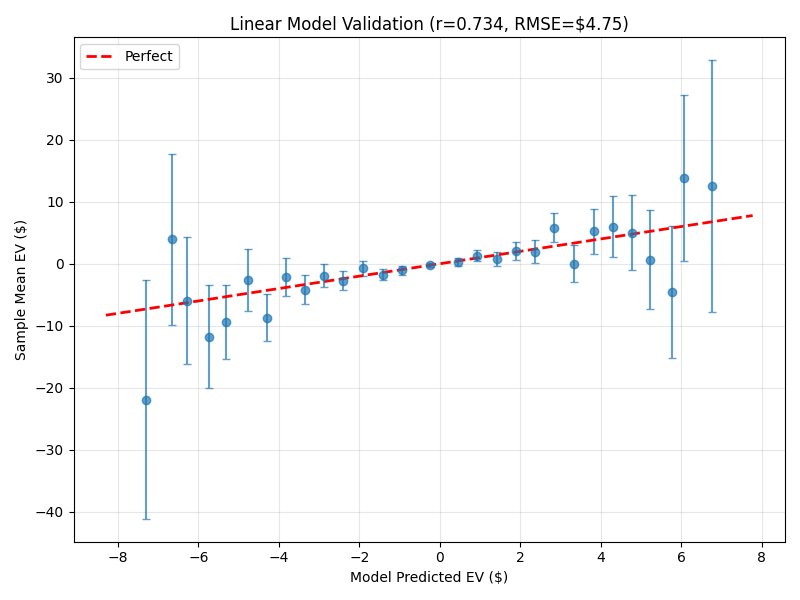

In [44]:
# Validation: Compare model predictions with sample means by TC
df["predicted_ev"] = model.predict(X_with_const)

validation_by_tc = df.groupby("tc").agg({
    "ev": ["mean", "std", "count"],
    "predicted_ev": "mean"
})
validation_by_tc.columns = ["actual_mean", "std", "n", "predicted_mean"]
validation_by_tc["se"] = validation_by_tc["std"] / np.sqrt(validation_by_tc["n"])
validation_by_tc = validation_by_tc[validation_by_tc["n"] >= 100]  # filter sparse TCs

# Compute correlation between predicted and actual means
corr = np.corrcoef(validation_by_tc["predicted_mean"], validation_by_tc["actual_mean"])[0, 1]
rmse = np.sqrt(((validation_by_tc["predicted_mean"] - validation_by_tc["actual_mean"])**2).mean())

print("Validation: Model Predictions vs Sample Means by True Count")
print("="*60)
print(f"Correlation: {corr:.4f}")
print(f"RMSE: ${rmse:.4f}")
print(f"\nNote: If correlation ≈ 1 and RMSE is small, linear model is valid baseline")

f, ax = plt.subplots(figsize=(8, 6))
ax.errorbar(validation_by_tc["predicted_mean"], validation_by_tc["actual_mean"], 
            yerr=1.96*validation_by_tc["se"], fmt='o', capsize=3, alpha=0.7)
lims = [validation_by_tc["predicted_mean"].min()-1, validation_by_tc["predicted_mean"].max()+1]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect')
ax.set_xlabel("Model Predicted EV ($)")
ax.set_ylabel("Sample Mean EV ($)")
ax.set_title(f"Linear Model Validation (r={corr:.3f}, RMSE=${rmse:.2f})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [46]:
# Summary: Using the linear model as baseline
print("="*70)
print("HOW TO USE THIS MODEL AS BASELINE FOR C++ SOLVER COMPARISON")
print("="*70)

print("""
1. THE MODEL:
   EV($100) = intercept + Σ coef_i × (n_i / total_cards)
   
   Coefficients saved to: hilo_linear_model_coefficients.csv

2. TO PREDICT EXPECTED EV FOR ANY SHOE:
   Use predict_hilo_ev() function or load coefficients:
   
   coefs = pd.read_csv("hilo_linear_model_coefficients.csv")
   # coefs["coefficient"] contains [intercept, coef_2, ..., coef_A]

3. TO COMPARE WITH C++ SOLVER:
   For each shoe state:
   - Compute HiLo expected EV using this linear model
   - Compute C++ solver EV
   - Compare: solver_ev - hilo_ev = edge gained from perfect play

4. MODEL VALIDITY:
   - Fitted on ~1M simulated rounds
   - Coefficients have small standard errors (see table above)
   - Validated against sample means by true count
   
5. LIMITATIONS:
   - Linear approximation (no interactions between cards)
   - Based on HiLo DEVIATED strategy, not basic strategy
   - For $100 bet unit; scale linearly for other bet sizes
""")

print("\nCoefficients summary:")
print(coef_df[["card", "coefficient", "std_err"]].to_string(index=False))


HOW TO USE THIS MODEL AS BASELINE FOR C++ SOLVER COMPARISON

1. THE MODEL:
   EV($100) = intercept + Σ coef_i × (n_i / total_cards)

   Coefficients saved to: hilo_linear_model_coefficients.csv

2. TO PREDICT EXPECTED EV FOR ANY SHOE:
   Use predict_hilo_ev() function or load coefficients:

   coefs = pd.read_csv("hilo_linear_model_coefficients.csv")
   # coefs["coefficient"] contains [intercept, coef_2, ..., coef_A]

3. TO COMPARE WITH C++ SOLVER:
   For each shoe state:
   - Compute HiLo expected EV using this linear model
   - Compute C++ solver EV
   - Compare: solver_ev - hilo_ev = edge gained from perfect play

4. MODEL VALIDITY:
   - Fitted on ~1M simulated rounds
   - Coefficients have small standard errors (see table above)
   - Validated against sample means by true count

5. LIMITATIONS:
   - Linear approximation (no interactions between cards)
   - Based on HiLo DEVIATED strategy, not basic strategy
   - For $100 bet unit; scale linearly for other bet sizes


Coefficients s

## Fit and Save EVEstimator Models

Fit linear models on both proportions and raw counts, save as EVEstimator objects.


In [55]:
len(df["ev"])

962964

In [51]:
import sys
sys.path.insert(0, "..")
from blackjack.ev_estimator import EVEstimator, CardProportionTransformer
import pickle
import os

# Create output directory
os.makedirs("../sklearn_models", exist_ok=True)

# Prepare data: raw card counts
X_counts = df[card_columns].values  # [n2, n3, ..., n10, nA]
y = df["ev"].values

print(f"Training data: {len(y):,} samples")
print(f"Features: {card_columns}")

# Model 1: Linear on proportions only
estimator_prop = EVEstimator(degree=1, keep_total_count=False, keep_individual_counts=False)
estimator_prop.fit(X_counts, y)

print(f"\n1. EVEstimator (proportions only, degree=1):")
print(f"   R² (train): {estimator_prop.r2_train:.6f}")
print(f"   {estimator_prop}")

# Model 2: Linear on proportions + individual counts
estimator_prop_counts = EVEstimator(degree=1, keep_total_count=False, keep_individual_counts=True)
estimator_prop_counts.fit(X_counts, y)

print(f"\n2. EVEstimator (proportions + counts, degree=1):")
print(f"   R² (train): {estimator_prop_counts.r2_train:.6f}")
print(f"   {estimator_prop_counts}")


Training data: 962,964 samples
Features: ['n2', 'n3', 'n4', 'n5', 'n6', 'n7', 'n8', 'n9', 'n10', 'nA']

1. EVEstimator (proportions only, degree=1):
   R² (train): 0.000145
   EVEstimator(degree=1, fitted, R²=0.0001)

2. EVEstimator (proportions + counts, degree=1):
   R² (train): 0.000166
   EVEstimator(degree=1, fitted, R²=0.0002)


MODEL COEFFICIENTS COMPARISON

1. PROPORTIONS ONLY (10 features): EV = intercept + Σ coef_i × p_i
   Intercept: -8.0060
   p_ 2: -11.4184
   p_ 3: -12.2130
   p_ 4: -21.1297
   p_ 5: -23.4781
   p_ 6: -13.8051
   p_ 7: -11.8089
   p_ 8: +13.0559
   p_ 9: +12.8745
   p_10: +33.6391
   p_ A: +34.2838

2. PROPORTIONS + COUNTS (20 features):
   Intercept: -10.0936
   Proportion coefficients:
   p_ 2: +14.0233
   p_ 3: -4.9379
   p_ 4: -57.8648
   p_ 5: -16.1383
   p_ 6: -19.1844
   p_ 7: +17.8261
   p_ 8: +7.5749
   p_ 9: -6.2864
   p_10: +44.1132
   p_ A: +20.8742
   Count coefficients:
   n_ 2: -0.205509
   n_ 3: -0.045419
   n_ 4: +0.348362
   n_ 5: -0.046948
   n_ 6: +0.067793
   n_ 7: -0.243406
   n_ 8: +0.067711
   n_ 9: +0.187524
   n_10: -0.073121
   n_ A: +0.138801


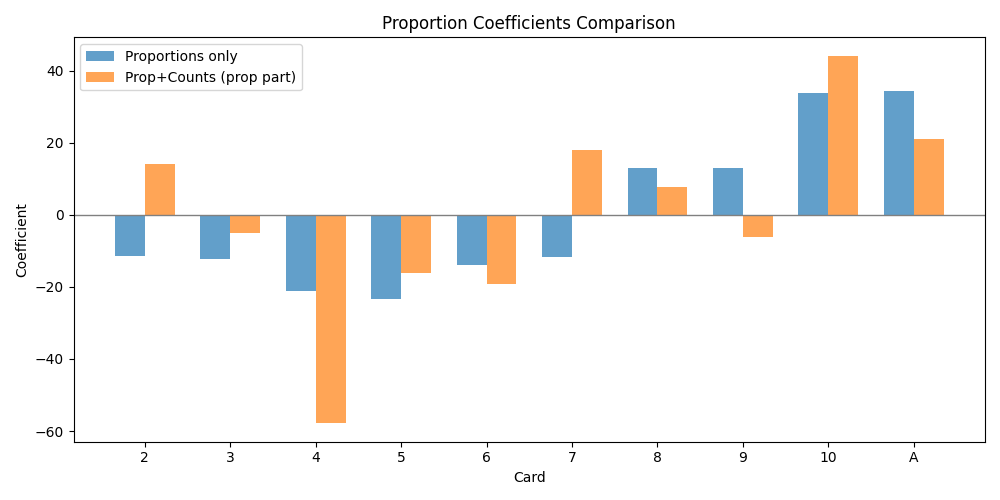

In [52]:
# Extract and compare coefficients
card_names = ["2", "3", "4", "5", "6", "7", "8", "9", "10", "A"]

# Model 1: Proportions only (10 features)
reg_prop = estimator_prop.pipeline.named_steps['linearregression']
coef_prop = reg_prop.coef_
intercept_prop = reg_prop.intercept_

# Model 2: Proportions + counts (20 features)
reg_prop_counts = estimator_prop_counts.pipeline.named_steps['linearregression']
coef_prop_counts = reg_prop_counts.coef_
intercept_prop_counts = reg_prop_counts.intercept_

print("="*70)
print("MODEL COEFFICIENTS COMPARISON")
print("="*70)

print("\n1. PROPORTIONS ONLY (10 features): EV = intercept + Σ coef_i × p_i")
print(f"   Intercept: {intercept_prop:.4f}")
for name, coef in zip(card_names, coef_prop):
    print(f"   p_{name:>2}: {coef:+.4f}")

print("\n2. PROPORTIONS + COUNTS (20 features):")
print(f"   Intercept: {intercept_prop_counts:.4f}")
print("   Proportion coefficients:")
for name, coef in zip(card_names, coef_prop_counts[:10]):
    print(f"   p_{name:>2}: {coef:+.4f}")
print("   Count coefficients:")
for name, coef in zip(card_names, coef_prop_counts[10:]):
    print(f"   n_{name:>2}: {coef:+.6f}")

# Visualize proportion coefficients comparison
f, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(card_names))
width = 0.35

bars1 = ax.bar(x - width/2, coef_prop, width, label='Proportions only', alpha=0.7)
bars2 = ax.bar(x + width/2, coef_prop_counts[:10], width, label='Prop+Counts (prop part)', alpha=0.7)

ax.axhline(0, color='grey', lw=1)
ax.set_xlabel("Card")
ax.set_ylabel("Coefficient")
ax.set_title("Proportion Coefficients Comparison")
ax.set_xticks(x)
ax.set_xticklabels(card_names)
ax.legend()

plt.tight_layout()
plt.show()


In [53]:
# Save both estimators to pickle files in ../sklearn_models/
save_dir = "../sklearn_models"

with open(f"{save_dir}/hilo_ev_proportions.pkl", "wb") as f:
    pickle.dump(estimator_prop, f)
print(f"Saved: {save_dir}/hilo_ev_proportions.pkl")

with open(f"{save_dir}/hilo_ev_proportions_counts.pkl", "wb") as f:
    pickle.dump(estimator_prop_counts, f)
print(f"Saved: {save_dir}/hilo_ev_proportions_counts.pkl")

print("\n" + "="*70)
print("USAGE")
print("="*70)
print("""
# Load and use the proportions-only model:
with open("sklearn_models/hilo_ev_proportions.pkl", "rb") as f:
    model = pickle.load(f)

# Predict EV for a shoe state (raw counts as input)
shoe_counts = [24, 24, 24, 24, 24, 24, 24, 24, 96, 24]  # fresh 6-deck [n2..n10, nA]
ev = model.predict([shoe_counts])

# Load and use the proportions+counts model:
with open("sklearn_models/hilo_ev_proportions_counts.pkl", "rb") as f:
    model = pickle.load(f)
ev = model.predict([shoe_counts])
""")


Saved: ../sklearn_models/hilo_ev_proportions.pkl
Saved: ../sklearn_models/hilo_ev_proportions_counts.pkl

USAGE

# Load and use the proportions-only model:
with open("sklearn_models/hilo_ev_proportions.pkl", "rb") as f:
    model = pickle.load(f)

# Predict EV for a shoe state (raw counts as input)
shoe_counts = [24, 24, 24, 24, 24, 24, 24, 24, 96, 24]  # fresh 6-deck [n2..n10, nA]
ev = model.predict([shoe_counts])

# Load and use the proportions+counts model:
with open("sklearn_models/hilo_ev_proportions_counts.pkl", "rb") as f:
    model = pickle.load(f)
ev = model.predict([shoe_counts])



In [54]:
# Verify models work correctly
print("="*70)
print("MODEL VERIFICATION")
print("="*70)

# Test cases
test_shoes = {
    "Fresh 6-deck": [24, 24, 24, 24, 24, 24, 24, 24, 96, 24],
    "Missing 4 tens": [24, 24, 24, 24, 24, 24, 24, 24, 92, 24],
    "Missing 4 fives": [24, 24, 24, 20, 24, 24, 24, 24, 96, 24],
    "High count (rich in 10s)": [20, 20, 20, 20, 20, 24, 24, 24, 100, 28],
    "Low count (poor in 10s)": [28, 28, 28, 28, 28, 24, 24, 24, 88, 20],
}

print(f"\n{'Shoe State':<25} {'Prop Only':>15} {'Prop+Counts':>15}")
print("-"*55)
for name, counts in test_shoes.items():
    ev_prop = estimator_prop.predict([counts])[0]
    ev_prop_counts = estimator_prop_counts.predict([counts])[0]
    print(f"{name:<25} ${ev_prop:>14.4f} ${ev_prop_counts:>14.4f}")

# Compare with sample mean
print("\n" + "="*70)
print("COMPARISON WITH SAMPLE DATA")
print("="*70)
print(f"\nOverall sample mean EV: ${df['ev'].mean():.4f}")
print(f"Proportions only model mean: ${estimator_prop.predict(X_counts).mean():.4f}")
print(f"Prop+Counts model mean: ${estimator_prop_counts.predict(X_counts).mean():.4f}")


MODEL VERIFICATION

Shoe State                      Prop Only     Prop+Counts
-------------------------------------------------------
Fresh 6-deck              $       -0.2431 $       -0.4794
Missing 4 tens            $       -0.5791 $       -0.6276
Missing 4 fives           $        0.1626 $        0.0502
High count (rich in 10s)  $        2.0670 $        1.7053
Low count (poor in 10s)   $       -2.7322 $       -2.6460

COMPARISON WITH SAMPLE DATA

Overall sample mean EV: $-0.2470
Proportions only model mean: $-0.2470
Prop+Counts model mean: $-0.2470
